In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

## Lab 13- Bootstrapping and Central Limit Theorem

### 1. Data Exploration

In [2]:
#load dataset
tbl = Table.read_table('https://raw.githubusercontent.com/lujiec2020/UMBC-IS296-Fall2022/main/data/baby.csv')
tbl

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


sample mean= 119.462521295


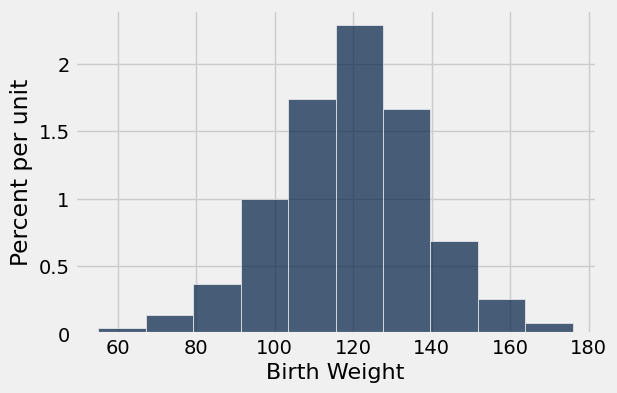

In [3]:
# plot histogram of a variable of interest and calculate a sample estimate of interest
tbl.hist('Birth Weight')
my_variable = tbl.column('Birth Weight')
my_estimate = np.mean(my_variable)  # update
print ('sample mean=',my_estimate) # update

### 2. Quantify Uncertainty of  Sample Esimate using Boostrapping (95% Confidence Interval )

In [4]:
def one_bootstrap():
    single_sample = tbl.sample()
    return np.mean(single_sample.column('Birth Weight'))

In [5]:
one_bootstrap()

118.52725724020443

In [6]:
bootstrap_result = make_array()
for i in np.arange(1000):
    new_estimate = one_bootstrap()
    bootstrap_result = np.append(bootstrap_result, new_estimate)
bootstrap_result


array([ 119.23424191,  119.04173765,  119.45741056,  119.84327087,
        119.42759796,  118.58432709,  119.33645656,  118.96678024,
        119.37819421,  118.72657581,  118.85264055,  119.41226576,
        118.5076661 ,  118.35689949,  119.23424191,  119.12265758,
        119.21550256,  118.81431005,  119.20272572,  117.62691652,
        120.72146508,  119.32708688,  118.95400341,  118.72657581,
        120.00681431,  120.06303237,  119.11669506,  120.17802385,
        119.05366269,  119.64991482,  119.21124361,  118.96422487,
        119.81005111,  120.21294719,  119.28705281,  119.93270869,
        119.35519591,  118.68994889,  119.81686542,  119.21039182,
        120.21805792,  120.14906303,  119.33816014,  119.77768313,
        119.03833049,  119.41567291,  118.79727428,  119.35264055,
        119.6746167 ,  121.02470187,  118.73424191,  118.9770017 ,
        119.25553663,  119.62010221,  118.95655877,  119.48637138,
        120.43781942,  118.83560477,  119.53577513,  118.62606

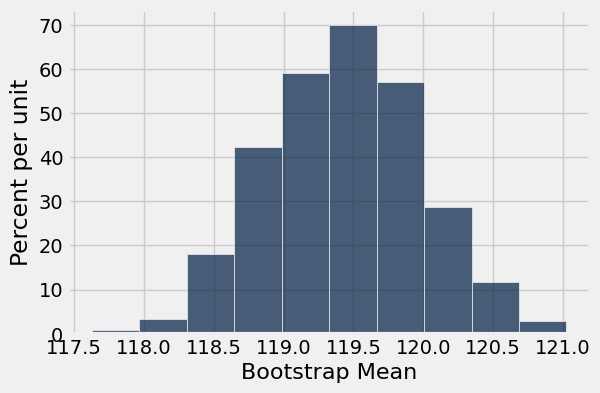

In [7]:
Table().with_column('Bootstrap Mean', bootstrap_result).hist('Bootstrap Mean')

In [8]:
#95% Confidence Interval
print('95% Confidence Interval of Sample Mean')
percentile(2.5, bootstrap_result), percentile(97.5, bootstrap_result)

95% Confidence Interval of Sample Mean


(118.396933560477, 120.50255536626916)

### 3. Quantify Uncertainty of  Sample Mean using Central Limit Theorem (95% Confidence Interval )

In [9]:
sample_mean = np.mean(tbl.column('Birth Weight'))
sample_size = tbl.num_rows
sample_std = np.std(tbl.column('Birth Weight'))

stderr = sample_std/np.sqrt(sample_size)
upper_CI = sample_mean + 1.96 * stderr
lower_CI = sample_mean - 1.96 * stderr
print('95% Confidence Interval of Sample Mean')
lower_CI, upper_CI

95% Confidence Interval of Sample Mean


(118.41450516524496, 120.51053742419286)